In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
from scipy.stats import skew

# Analiza baze podataka

In [4]:
df = pd.read_csv('data/heart.csv')

In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
print("Broj uzoraka i obelezja: \n", df.shape)
print("Tipovi obelezja: \n", df.dtypes)

Broj uzoraka i obelezja: 
 (918, 12)
Tipovi obelezja: 
 Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


In [7]:
print(df["HeartDisease"].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


# Vizuelizacija podataka

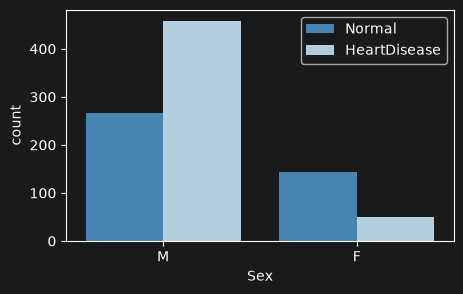

In [8]:
plt.figure(figsize=(5,3))
ax = sb.countplot(x='Sex', hue='HeartDisease', data=df,palette='Blues_r')
plt.legend(labels=['Normal', 'HeartDisease'])
plt.show()

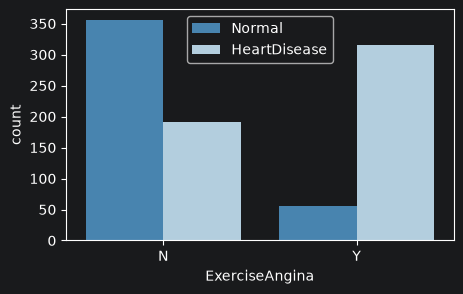

In [9]:
plt.figure(figsize=(5,3))
ax = sb.countplot(x='ExerciseAngina', hue='HeartDisease', data=df, palette='Blues_r')
plt.legend(labels=['Normal', 'HeartDisease'])
plt.show()

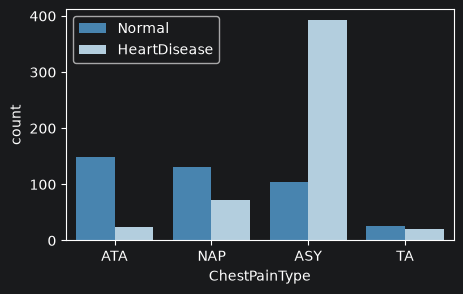

In [10]:
plt.figure(figsize=(5,3))
ax = sb.countplot(x='ChestPainType', hue='HeartDisease', data=df, palette='Blues_r')
plt.legend(labels=['Normal', 'HeartDisease'])
plt.show()

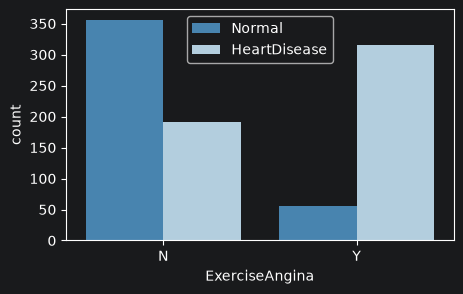

In [11]:
plt.figure(figsize=(5,3))
ax = sb.countplot(x='ExerciseAngina', hue='HeartDisease', data=df,palette='Blues_r')
plt.legend(labels=['Normal', 'HeartDisease'])
plt.show()

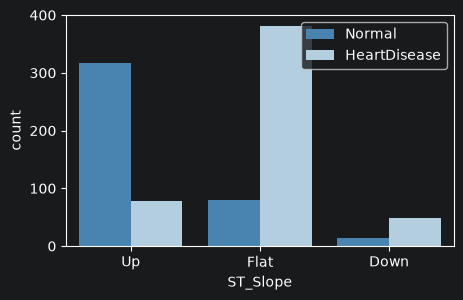

In [12]:
plt.figure(figsize=(5,3))
ax = sb.countplot(x='ST_Slope', hue='HeartDisease', data=df,palette='Blues_r')
plt.legend(labels=['Normal', 'HeartDisease'])
plt.show()

C:\Users\Nemanja\AppData\Local\Temp\ipykernel_4300\333189911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x='HeartDisease', data=df, palette='Blues_r')


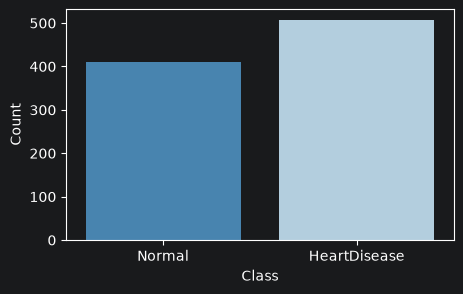

In [42]:
plt.figure(figsize=(5,3))
ax = sb.countplot(x='HeartDisease', data=df, palette='Blues_r')
plt.xticks([0, 1], ['Normal', 'HeartDisease'])
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [14]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [15]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [16]:
df[['Cholesterol','RestingBP']].describe()

,Cholesterol,RestingBP
count,918.000000,918.000000
mean,198.799564,132.396514
std,109.384145,18.514154
min,0.000000,0.000000
25%,173.250000,120.000000
50%,223.000000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


In [17]:
(df['RestingBP'] == 0).sum()

np.int64(1)

In [18]:
df[df["RestingBP"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [19]:
df.drop(df[df["RestingBP"] == 0].index, inplace=True)

In [20]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,199.016358,0.233370,136.789531,0.886696,0.552890
std,9.437636,17.999749,109.246330,0.423206,25.467129,1.066960,0.497466
min,28.000000,80.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,174.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [21]:
(df['Oldpeak']<0).sum()

np.int64(13)

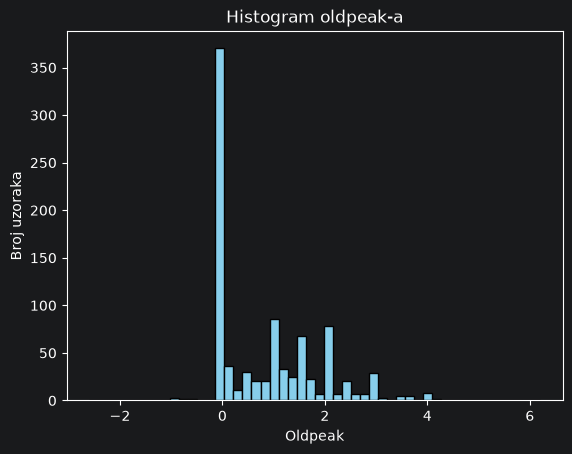

In [22]:
plt.hist(df["Oldpeak"], bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram oldpeak-a")
plt.xlabel("Oldpeak")
plt.ylabel("Broj uzoraka")
plt.show()

In [23]:
df['Sex'].unique()

<StringArray>
['M', 'F']
Length: 2, dtype: str

In [24]:
df = pd.get_dummies(df, columns=["Sex"], drop_first=True)

In [25]:
df['ChestPainType'].unique()

<StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str

In [26]:
df = pd.get_dummies(df, columns=["ChestPainType"], drop_first=True)

In [27]:
df['RestingECG'].unique()

<StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str

In [28]:
df = pd.get_dummies(df, columns=["RestingECG"], drop_first=True)

In [29]:
df['ExerciseAngina'].unique()

<StringArray>
['N', 'Y']
Length: 2, dtype: str

In [30]:
df = pd.get_dummies(df, columns=["ExerciseAngina"], drop_first=True)

In [31]:
df['ST_Slope'].unique()

<StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str

In [32]:
df = pd.get_dummies(df, columns=["ST_Slope"], drop_first=True)

In [33]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [34]:
print("Udeo vrednosti gde je holesterol jednak nuli u odnosu na celu bazu je \n",(df['Cholesterol'] == 0).sum()/len(df)*100,'%')

Udeo vrednosti gde je holesterol jednak nuli u odnosu na celu bazu je 
 18.647764449291166 %


In [35]:
(df['Cholesterol'] == 0).sum()

np.int64(171)

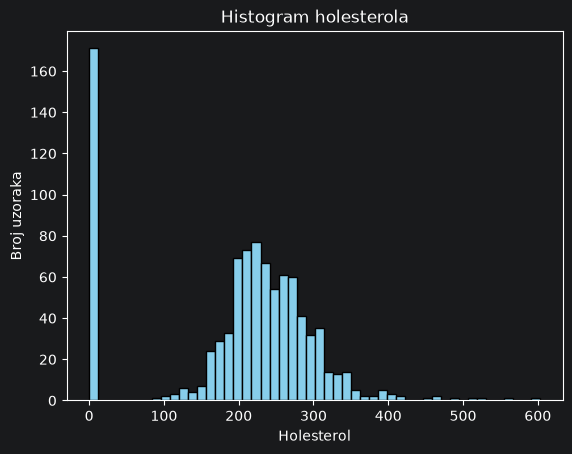

In [36]:
plt.hist(df["Cholesterol"], bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram holesterola")
plt.xlabel("Holesterol")
plt.ylabel("Broj uzoraka")
plt.show()

In [37]:
(df['Cholesterol']>500).sum()

np.int64(4)

koef.asimetrije mean dopunom:  1.37
koef.asimetrije median dopunom:  1.44


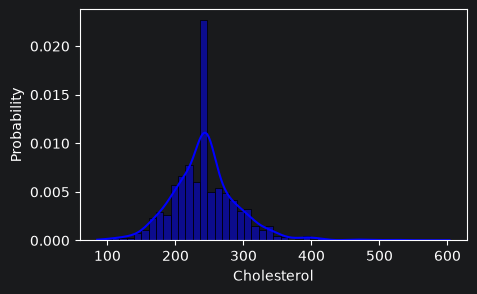

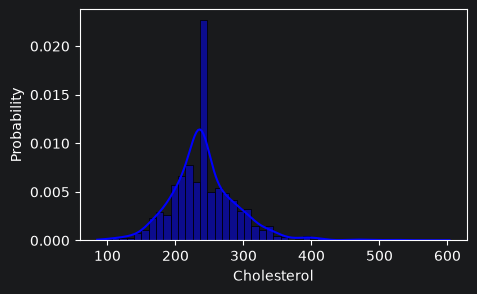

In [38]:
# Mean dopuna
df_mean = df.copy()
df_mean['Cholesterol'] = df_mean['Cholesterol'].replace(0, np.nan)
df_mean['Cholesterol'] = df_mean['Cholesterol'].fillna(df_mean['Cholesterol'].mean())

# Median dopuna
df_median = df.copy()
df_median['Cholesterol'] = df_median['Cholesterol'].replace(0, np.nan)
df_median['Cholesterol'] = df_median['Cholesterol'].fillna(df_median['Cholesterol'].median())


print('koef.asimetrije mean dopunom:  %.2f' % skew(df_mean['Cholesterol']))
print('koef.asimetrije median dopunom:  %.2f' % skew(df_median['Cholesterol']))

#Mean dopuna
plt.figure(figsize=(5,3))
sb.histplot(df_mean['Cholesterol'], kde=True, stat="density", color='blue')
plt.xlabel('Cholesterol')
plt.ylabel('Probability')
plt.show()

# Median dopuna
plt.figure(figsize=(5,3))
sb.histplot(df_median['Cholesterol'], kde=True, stat="density", color='blue')
plt.xlabel('Cholesterol')
plt.ylabel('Probability')
plt.show()

In [39]:
df_mean.describe()
df_mean.shape

(917, 16)

In [40]:
df_mean.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

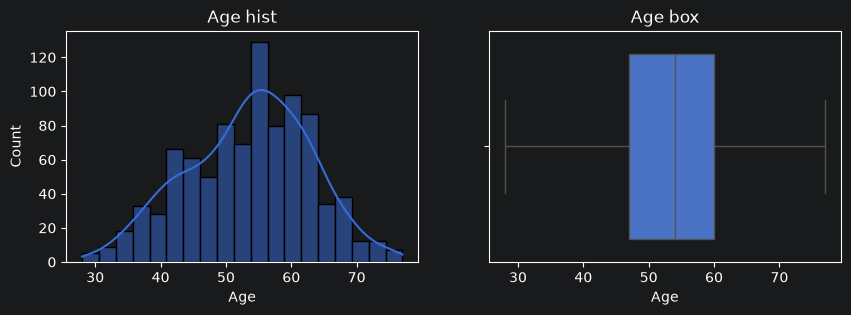

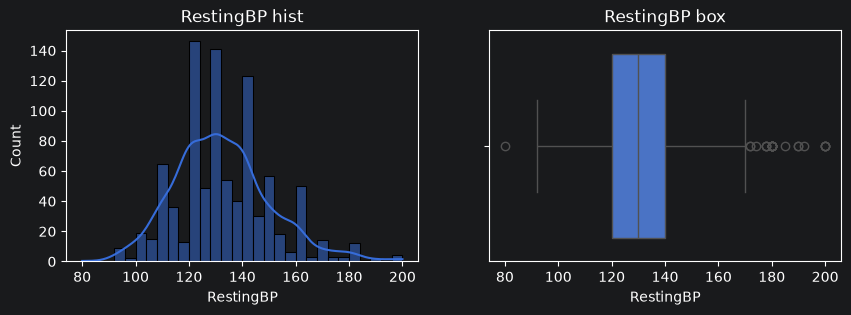

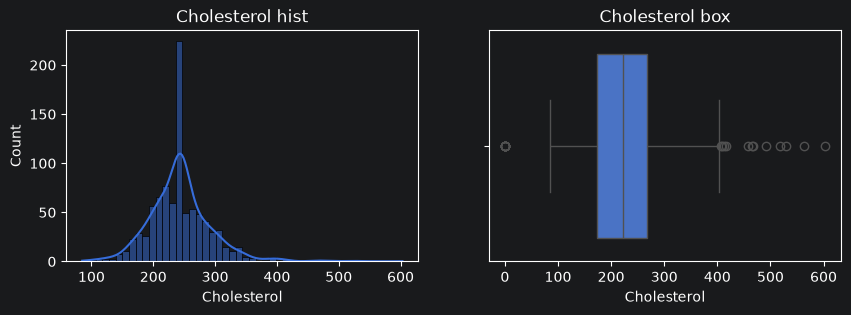

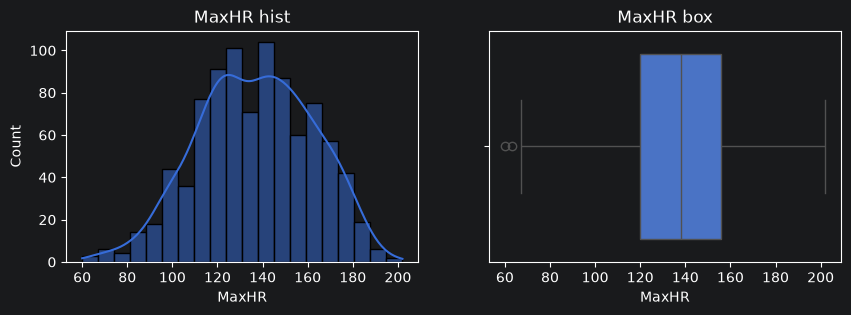

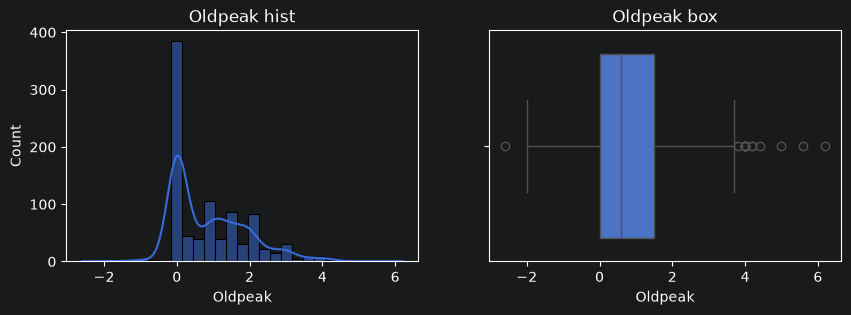

In [41]:
num_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
for c in num_cols:
    plt.figure(figsize=(10,3))
    plt.subplot(1,2,1)
    sb.histplot(df_mean[c], kde=True)
    plt.title(c + ' hist')

    plt.subplot(1,2,2)
    sb.boxplot(x=df[c])
    plt.title(c + ' box')

    plt.show()
